In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive

 1760462335778.jpg  'Colab Notebooks'   _copy.pdf  'Untitled folder'


In [ ]:
!ls /content/drive/MyDrive/Colab\ Notebooks

footballanalysis.ipynb	results.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/results.csv')
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  object 
 1   home_team   49287 non-null  object 
 2   away_team   49287 non-null  object 
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  object 
 6   city        49287 non-null  object 
 7   country     49287 non-null  object 
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/results.csv')
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  object 
 1   home_team   49287 non-null  object 
 2   away_team   49287 non-null  object 
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  object 
 6   city        49287 non-null  object 
 7   country     49287 non-null  object 
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [ ]:
df.describe()

,home_score,away_score
count,49215.000000,49215.000000
mean,1.756091,1.182404
std,1.770617,1.401770
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [ ]:
df.isnull().sum()

,0
date,0
home_team,0
away_team,0
home_score,72
away_score,72
tournament,0
city,0
country,0
neutral,0


## Question 1
How many matches are in the dataset?

We solve this by counting the number of rows, since each row represents a match.

In [ ]:
df.shape[0]

49287

## Question 2: What is the earliest and latest year in the data?

The dataset contains a date column instead of a separate Year column.  
We first convert the date column to a proper datetime format, then extract the year.  
After that, we use minimum and maximum functions to find the earliest and latest years.

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['date'].dt.year.min(), df['date'].dt.year.max()

(1872, 2026)

## Question 3: How many unique countries are there?

We use the nunique() function on the Country column to count distinct values.  
Each unique value represents a different country in the dataset.

In [ ]:
df['country'].nunique()

269

## Question 4: Which team appears most frequently as the home team?

We count how many times each team appears as a home team using value_counts().  
Then we select the team with the highest frequency using idxmax().

In [ ]:
df['home_team'].value_counts().idxmax()

'Brazil'

## Question 5: What is the average number of goals per match?

To find the average goals per match, we calculate the total goals scored in each match
(home goals + away goals), then compute the mean of these totals.

In [ ]:
df['TotalGoals'] = df['home_score'] + df['away_score']
df['TotalGoals'].mean()

np.float64(2.93849436147516)

# Question 6: What is the highest scoring match?
The highest scoring match is identified by calculating total goals (home + away) for each match and selecting the match with the maximum value. The corresponding teams and scoreline are then displayed.

In [ ]:
# Step 1: Create total goals column
df['TotalGoals'] = df['home_score'] + df['away_score']

# Step 2: Find the highest scoring value
max_goals = df['TotalGoals'].max()

# Step 3: Display the match (teams + score)
highest_scoring_match = df[df['TotalGoals'] == max_goals]

max_goals, highest_scoring_match

(31.0,
             date  home_team       away_team  home_score  away_score  \
 25420 2001-04-11  Australia  American Samoa        31.0         0.0   
 
                          tournament           city    country  neutral  \
 25420  FIFA World Cup qualification  Coffs Harbour  Australia    False   
 
        TotalGoals  
 25420        31.0  )

## Question 7: Are more goals scored at home or away?

We compare the total number of home goals and away goals separately by summing each column.
The larger total shows where more goals are scored.

In [ ]:
home_goals = df['home_score'].sum()
away_goals = df['away_score'].sum()

if home_goals > away_goals:
    print("More goals are scored at home")
else:
    print("More goals are scored away")

More goals are scored at home


## Question 8: What is the most common total goals value?

We calculate total goals per match, then use value_counts() to find which total appears most frequently.

In [ ]:
df['TotalGoals'] = df['home_score'] + df['away_score']
df['TotalGoals'].value_counts().idxmax()

np.float64(2.0)

## Question 9: What percentage of matches are home wins?

A home win occurs when the home team scores more goals than the away team.  
We compare home and away goals for each match, count home wins, and calculate the percentage out of all matches.

In [ ]:
home_wins = (df['home_score'] > df['away_score']).sum()
total_matches = df.shape[0]

(home_wins / total_matches) * 100

np.float64(48.9094487390184)

## Question 10: Does home advantage exist?

Home advantage exists if the number of home wins is significantly higher than away wins or draws.  
We compare counts of home wins, away wins, and draws to determine this.

In [ ]:
home_wins = (df['home_score'] > df['away_score']).sum()
away_wins = (df['home_score'] < df['away_score']).sum()
draws = (df['home_score'] == df['away_score']).sum()

home_wins, away_wins, draws
if home_wins > away_wins:
    print("Home advantage exists")
else:
    print("No strong home advantage")

Home advantage exists


## Question 11: Which country has the most wins historically?

We identify wins based on match results and group them by country.  
The country with the highest number of wins is selected.

In [ ]:
df['Result'] = df.apply(
    lambda row: 'HomeWin' if row['home_score'] > row['away_score']
    else ('AwayWin' if row['home_score'] < row['away_score'] else 'Draw'),
    axis=1
)

# Count wins per country (home team wins as proxy)
df[df['Result'] == 'HomeWin']['country'].value_counts().idxmax()

'United States'

## Question 12(a): Histogram of goals

We create a histogram of total goals per match to show the distribution of match scoring.  
Total goals are calculated by adding home and away goals.

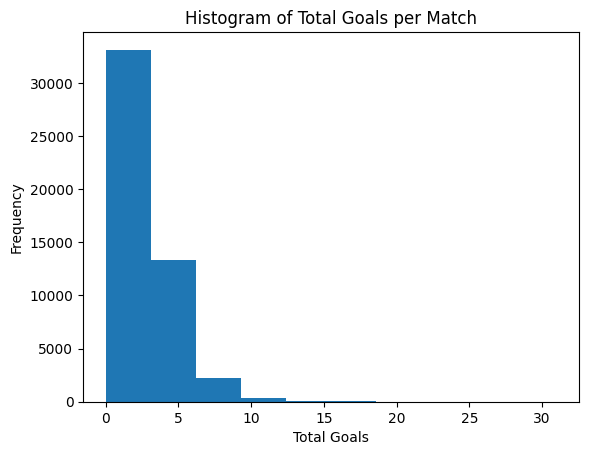

In [ ]:
import matplotlib.pyplot as plt

df['TotalGoals'] = df['home_score'] + df['away_score']

plt.hist(df['TotalGoals'], bins=10)
plt.title("Histogram of Total Goals per Match")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")
plt.show()

## Question 12(b): Bar chart of match outcomes

We classify each match as a Home Win, Away Win, or Draw based on goals scored,  
then plot a bar chart showing the frequency of each outcome.

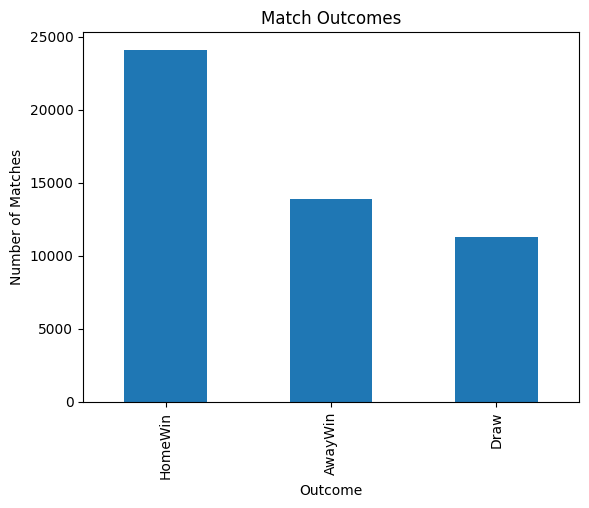

In [ ]:
import matplotlib.pyplot as plt

df['Result'] = df.apply(
    lambda row: 'HomeWin' if row['home_score'] > row['away_score']
    else ('AwayWin' if row['home_score'] < row['away_score'] else 'Draw'),
    axis=1
)

df['Result'].value_counts().plot(kind='bar')
plt.title("Match Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Matches")
plt.show()

## Question 12(c): Top ten teams by total wins

We count the number of home wins for each team and display the top 10 teams with the highest number of wins.

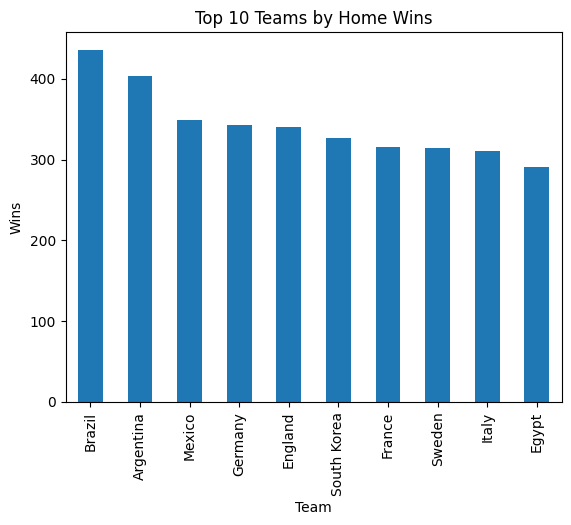

In [ ]:
home_wins = df[df['home_score'] > df['away_score']]
top_10_teams = home_wins['home_team'].value_counts().head(10)

top_10_teams.plot(kind='bar')
plt.title("Top 10 Teams by Home Wins")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.show()